# 04 · Backtest de producción — holdout de 14 días (horizonte de diseño)
**¿Cómo se ve el modelo en producción cuando se le pide justo lo que fue diseñado a entregar?**

Misma metodología que el notebook 03, pero con la ventana **al horizonte de diseño del modelo: 14 días** (16–29 feb 2024). Apartamos esos días, entrenamos con todo lo anterior, el modelo no los ve en nada, y emite el pronóstico de una sola vez.

La diferencia con el 03 es deliberada y esclarecedora. Allí estiramos el modelo a 30 días y vimos que se degradaba fuera de su horizonte (los rezagos de demanda desaparecían). **Aquí, a 14 días, todos los rezagos de 14/21/28 días siguen disponibles para toda la ventana** — el modelo opera con información completa, como fue concebido. Este notebook responde: *en su zona de diseño, ¿qué precisión entrega y cómo se ve la salida desglosada por formato y categoría?*

> Motor: `src.holdout.run_holdout` (misma función del pipeline `retail-holdout`), aquí con corte de 14 días. Gráficos en Plotly interactivo con respaldo PNG para GitHub.

In [1]:
import sys, warnings
sys.path.append("..")

import numpy as np
import pandas as pd
import plotly.graph_objects as go

from src import config, viz
from src.preprocesamiento.data import load_transactions, load_stores, load_calendar
from src.evaluacion.holdout import run_holdout, summarize_holdout, summarize_holdout_paired
from src.evaluacion.metrics import evaluate

warnings.filterwarnings("ignore")
viz.apply_plotly_style()

HOLDOUT_DIAS = 14
tx, stores, cal = load_transactions(), load_stores(), load_calendar()
cutoff = tx["date"].max() - pd.Timedelta(days=HOLDOUT_DIAS)
preds = run_holdout(tx, stores, cal, cutoff).merge(
    stores[["store_id", "store_format"]], on="store_id")

MODEL_COLORS = {"real": viz.INK, "gradient_boosting_prior": "#2a78d6",
                "sistema_actual": "#e34948", "naive_estacional": "#eda100"}
MODEL_LABELS = {"gradient_boosting_prior": "Modelo propuesto",
                "sistema_actual": "Sistema actual", "naive_estacional": "Naïve estacional"}
CAMPEON = "gradient_boosting_prior"
print(f"Corte de entrenamiento: {cutoff.date()}  (el modelo NO ve nada posterior)")
print(f"Ventana de backtest:   {(cutoff + pd.Timedelta(days=1)).date()} → {tx['date'].max().date()}"
      f"  ({HOLDOUT_DIAS} días)")

Corte de entrenamiento: 2024-02-15  (el modelo NO ve nada posterior)
Ventana de backtest:   2024-02-16 → 2024-02-29  (14 días)


## 1 · Métricas globales

WAPE con IC 95% (bootstrap por bloques de fecha) y la prueba pareada de significancia (el campeón gana solo si el IC de la diferencia no cruza cero).

In [2]:
met = summarize_holdout(preds)
tabla = met[met["tramo"] == "total"].set_index("modelo")
resumen = pd.DataFrame({
    "WAPE": tabla["wape"].round(3),
    "IC 95%": [f"[{lo:.3f}, {hi:.3f}]" for lo, hi in zip(tabla["wape_lo"], tabla["wape_hi"])],
    "MAE": tabla["mae"].round(0), "Sesgo": tabla["bias"].round(3),
}).reindex(["gradient_boosting_prior", "sistema_actual", "naive_estacional"])
resumen.index = [MODEL_LABELS[m] for m in resumen.index]
print("Desempeño sobre los 14 días apartados:\n")
print(resumen.to_string())
print("\nΔWAPE pareado (campeón − rival; negativo = campeón mejor):")
print(summarize_holdout_paired(preds).round(3).to_string(index=False))

Desempeño sobre los 14 días apartados:

                   WAPE          IC 95%    MAE  Sesgo
Modelo propuesto  0.239  [0.235, 0.243]  246.0 -0.029
Sistema actual    0.289  [0.265, 0.316]  297.0 -0.006
Naïve estacional  0.268  [0.259, 0.275]  275.0 -0.041

ΔWAPE pareado (campeón − rival; negativo = campeón mejor):
                               comparacion delta_wape  delta_lo  delta_hi significativo n_dias
  gradient_boosting_prior − sistema_actual  -0.049529 -0.076857 -0.024894          True     14
gradient_boosting_prior − naive_estacional  -0.028378 -0.034708 -0.021929          True     14


**Dentro de su horizonte de diseño, el modelo es el mejor y la ventaja es significativa.** WAPE 0.239 vs 0.289 del sistema actual (−5 pp) y 0.268 del naïve, con los IC de las diferencias pareadas enteramente por debajo de cero. El contraste con el notebook 03 es la lección central del proyecto: **el modelo entrega valor dentro de su horizonte de 14 días; más allá, hay que re-emitir.**

### ¿Se degrada dentro de la ventana?

In [3]:
preds["dias_desde_corte"] = (preds["date"] - cutoff).dt.days
preds["tramo_h"] = pd.cut(preds["dias_desde_corte"], [0, 7, 14],
                          labels=["días 1-7", "días 8-14"])
camp = preds[preds["modelo"] == CAMPEON]
print("Modelo propuesto por tramo (a 14 días NO se degrada — todos los rezagos siguen vivos):")
print(evaluate(camp, by=["tramo_h"])[["tramo_h", "n", "wape", "bias"]].round(3).to_string(index=False))

Modelo propuesto por tramo (a 14 días NO se degrada — todos los rezagos siguen vivos):
  tramo_h    n  wape   bias
 días 1-7 3242 0.240 -0.030
días 8-14 3253 0.238 -0.029


## 2 · La salida desglosada

La misma serie de tiempo (real vs. pronóstico de cada modelo) vista a distintos niveles de agregación: la cadena completa, luego cada formato de tienda, luego cada categoría. Así se ve si el buen desempeño global se sostiene al bajar de nivel — que es donde se decide la reposición. *Hover para valores exactos; en GitHub se muestra la versión estática.*

In [4]:
def plot_grupo(sub, titulo, altura=380):
    """Serie de tiempo real vs. modelos, agregada (suma diaria) sobre el
    subconjunto dado. Fechas como strings ISO para compatibilidad con la
    exportación PNG de kaleido."""
    fechas = pd.date_range(sub["date"].min(), sub["date"].max(), freq="D")
    fechas_x = [d.strftime("%Y-%m-%d") for d in fechas]

    def serie(modelo, valor):
        s = sub[sub["modelo"] == modelo].groupby("date")[valor].sum() / 1e3
        return s.reindex(fechas).to_numpy()

    fig = go.Figure()
    fig.add_scatter(x=fechas_x, y=serie(CAMPEON, "y_true"), mode="lines+markers",
                    name="Real", line=dict(color=MODEL_COLORS["real"], width=2.6),
                    marker=dict(size=5),
                    hovertemplate="%{x|%a %d %b}<br>Real: <b>%{y:.0f}k uds</b><extra></extra>")
    for modelo in ["gradient_boosting_prior", "sistema_actual", "naive_estacional"]:
        fig.add_scatter(x=fechas_x, y=serie(modelo, "y_pred"), mode="lines",
                        name=MODEL_LABELS[modelo],
                        line=dict(color=MODEL_COLORS[modelo], width=1.8),
                        hovertemplate="%{x|%a %d %b}<br>" + MODEL_LABELS[modelo]
                                      + ": <b>%{y:.0f}k uds</b><extra></extra>")
    fig.update_layout(title=titulo, yaxis_title="miles de unidades / día", height=altura,
                      hovermode="x unified",
                      legend=dict(orientation="h", y=1.14, font=dict(size=10)))
    return fig

### 2.1 · General — cadena completa

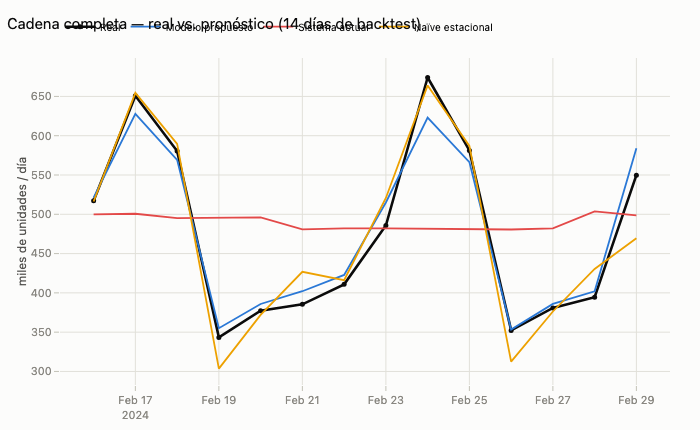

In [5]:
plot_grupo(preds, "Cadena completa — real vs. pronóstico (14 días de backtest)", altura=430).show()

### 2.2 · Por formato de tienda

Una gráfica por formato. Recuerda del EDA que los formatos tienen escalas y economías distintas (Supercenter vende ~3.5× un Express en absoluto), por eso se grafican por separado.

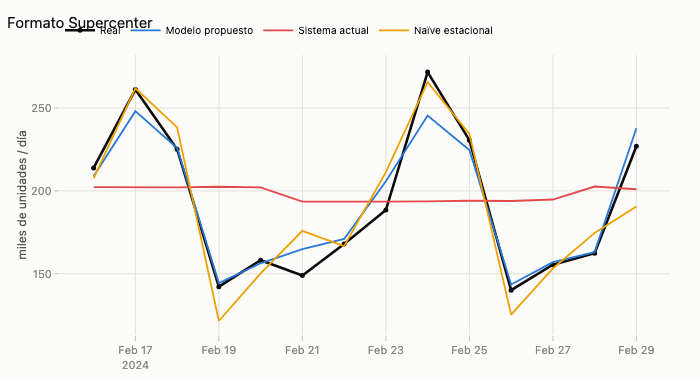

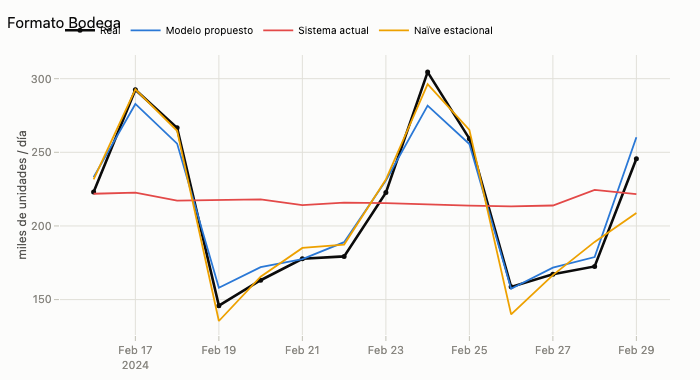

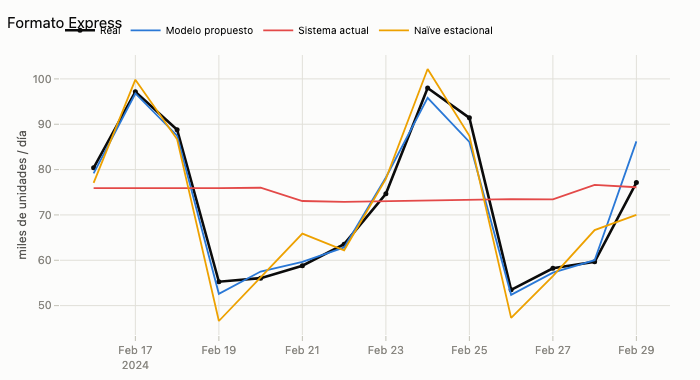

In [6]:
for fmt in config.STORE_FORMATS:
    plot_grupo(preds[preds["store_format"] == fmt], f"Formato {fmt}").show()

In [7]:
wf = evaluate(camp, by=["store_format"]).set_index("store_format").loc[config.STORE_FORMATS]
print("WAPE del modelo por formato:")
print(wf[["wape", "mae", "bias"]].round(3).to_string())

WAPE del modelo por formato:
               wape      mae   bias
store_format                       
Supercenter   0.244  403.851 -0.031
Bodega        0.236  248.626 -0.027
Express       0.236  116.975 -0.032


### 2.3 · Por categoría

Una gráfica por cada una de las 6 categorías (suma sobre las 80 tiendas).

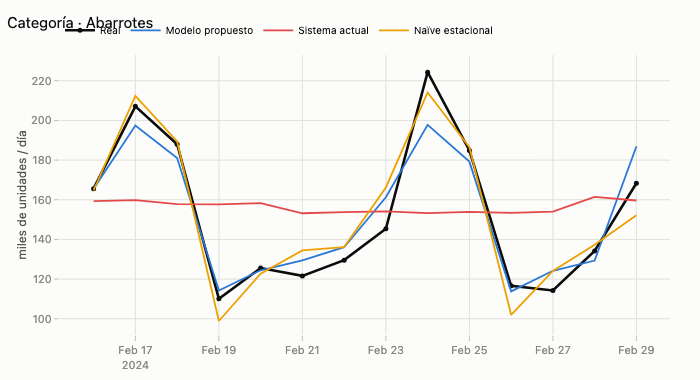

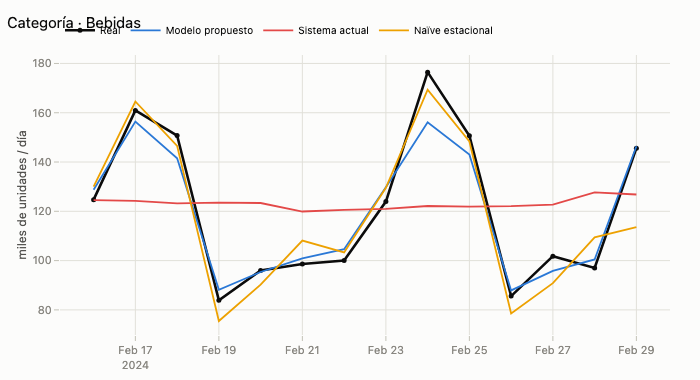

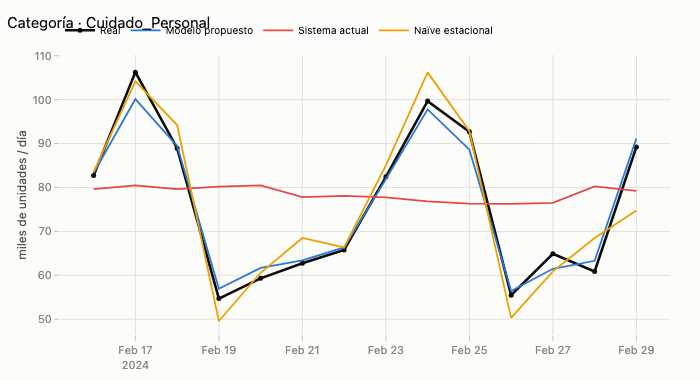

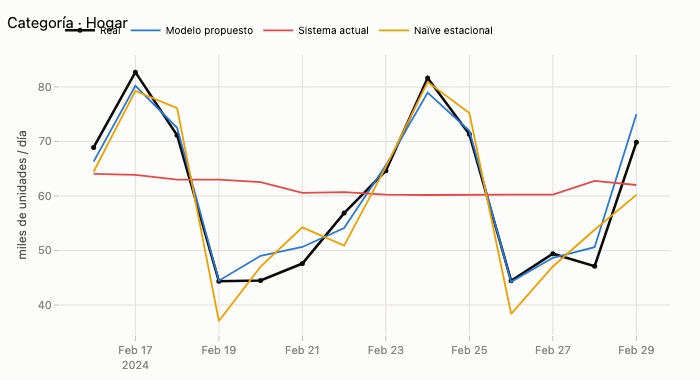

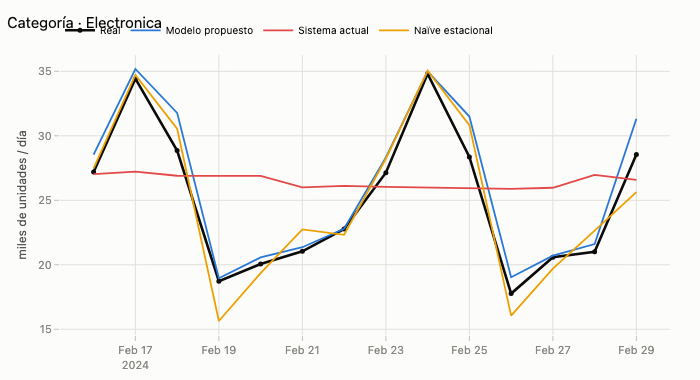

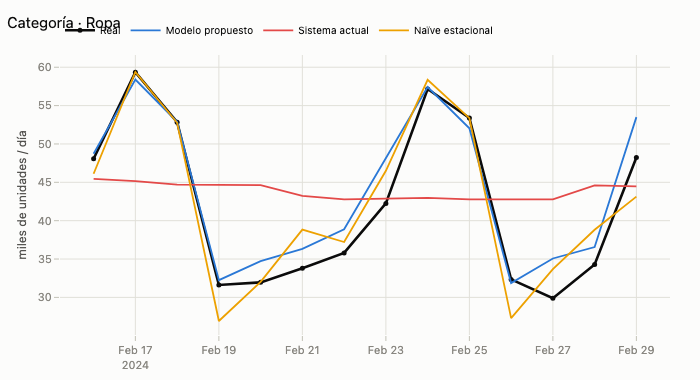

In [8]:
for cat in config.CATEGORIES:
    plot_grupo(preds[preds["category"] == cat], f"Categoría · {cat}").show()

In [9]:
wc = evaluate(camp, by=["category"]).set_index("category").loc[config.CATEGORIES]
print("WAPE del modelo por categoría:")
print(wc[["wape", "mae", "bias"]].round(3).to_string())

WAPE del modelo por categoría:
                   wape      mae   bias
category                               
Abarrotes         0.237  468.702 -0.038
Bebidas           0.241  374.662 -0.036
Cuidado_Personal  0.243  240.085 -0.037
Hogar             0.242  187.617 -0.021
Electronica       0.233   75.957 -0.000
Ropa              0.234  128.395  0.005


## 3 · Lectura

- **En su horizonte de diseño, el modelo pronostica los 14 días con WAPE 0.239 y le gana a ambos baselines con significancia estadística** (ΔWAPE pareado con IC bajo cero), pese a que el sistema actual usa la señal emitida *durante* esos días.
- **No hay degradación dentro de la ventana** (días 1-7: 0.240; días 8-14: 0.238). Es el contraste directo con el notebook 03: a 14 días todos los rezagos de demanda siguen vivos, así que el modelo nunca se queda "a ciegas" como sí ocurría en el tramo lejano de los 30 días.
- **El buen desempeño se sostiene al desglosar:** WAPE 0.236–0.244 en los 3 formatos y 0.233–0.243 en las 6 categorías, con sesgo pequeño en todos. No hay un formato o categoría donde el modelo falle — la mejora es transversal al negocio, no un promedio que esconde huecos. En las gráficas se ve que la línea del modelo (azul) sigue de cerca la real (negra) en cada panel, mientras el sistema actual (rojo) va sistemáticamente rezagado y aplana los picos de fin de semana.
- Ventana sin Buen Fin ni Navidad → prior neutro; este backtest mide el desempeño *base* fuera de picos (el manejo de eventos vive en el notebook 02).

**Síntesis de los dos backtests (03 y 04):** el modelo aporta valor claro y significativo **dentro de su horizonte de 14 días** y a todos los niveles de agregación del negocio. Fuera de él pierde su ventaja. La recomendación de producción que sale de ambos es la misma: **desplegar con re-emisión de origen rodante cada 1–2 semanas**, nunca un disparo largo.